In [1]:
import pandas as pd
import os
import random
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from xgboost import XGBClassifier
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
import seaborn as sns
import numpy as np

In [12]:
# data_file = os.path.join("data_set", "combined_statistical_features_all.csv")
# data_file = os.path.join("data_set", "combined_statistical_features.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_imu.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_imu_all_locations.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_imu_luo.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_imu_right_forearm.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_imu_pelvis.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_imu_pelvis_right_forearm.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_imu_pelvis_right_forearm_insoles.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_insoles_imu.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_insoles_pressure.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_insoles_pressure_imu.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_xsens_luo.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_xsens_all_insoles_all.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_xsens_best_insoles_best.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_imu_left_forearm.csv")
# data_file = os.path.join("data_set", "combined_magnitude_statistical_features_imu_luo_all_data_sources.csv")
# data_file = os.path.join("data_set", "combined_magnitude_statistical_features_imu_luo_only_acceleration.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_xsens_best_insoles_best_no_magnetometer.csv")
# data_file = os.path.join("data_set", "combined_statistical_and_frequency_features_xsens_best_insoles_best_no_magnetometer.csv")
# data_file = os.path.join("data_set", "combined_statistical_features_xsens_best_insoles_best_no_magnetometer(shank_based_gait_detection).csv")
# data_file = os.path.join("data_set", "combined_statistical_features_xsens_best_insoles_best_no_magnetometer(sliding window of 2 seconds with a step of 1 second).csv")
data_file = os.path.join("data_set", "combined_statistical_and_frequency_features_xsens_best_insoles_best_no_magnetometer(shank_based_gait_detection).csv")
df = pd.read_csv(data_file)
df = df.drop(columns=["stepcount"])
initial_row_count = df.shape[0]
# Drop rows with any NaN values
df = df.dropna()
# Get the number of rows after dropping NaN values
final_row_count = df.shape[0]
# Calculate how many rows were dropped
rows_dropped = initial_row_count - final_row_count
print(f"Number of rows dropped: {rows_dropped}")

# df = df.drop('window_start', axis=1)
# df = df.drop('window_end', axis=1)

# Replace class names with integers
unique_vals = df["walk_mode"].unique()

print (unique_vals)

# df["walk_mode"].replace(
#     to_replace=unique_vals, value=list(range(len(unique_vals))), inplace=True
# )

df["walk_mode"] = df["walk_mode"].replace(to_replace=unique_vals, value=list(range(len(unique_vals))))


# # move the Name column to the postition before the last, keeping the Task column as the last one
# col = df.pop("Name")
# df.insert(len(df.columns) - 1, col.name, col)

Number of rows dropped: 0
['walk' 'stairs_down' 'stairs_up' 'slope_down' 'slope_up']


C:\Users\ojlass\AppData\Local\Temp\ipykernel_728\3488426889.py:47: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["walk_mode"] = df["walk_mode"].replace(to_replace=unique_vals, value=list(range(len(unique_vals))))


In [13]:
def reduce_features(train_set, features, variance_threshold=0.01, max_corr=0.80):
    """this is the feature reduction method

    Parameters:
    train_set (dataframe): train set used to reduce the features
    features (list): initial feature names
    variance_threshold (float): variance threshold used to identify quasi-constant features
    max_corr (float): threshold to keep non-correlated features

    Returns:
    reduced_features (list): reduced feature names
    """

    print("reducing features...")

    X_train = train_set[features].copy()
    # Removing Constant features using variance threshold
    constant_filter = VarianceThreshold(threshold=0)
    constant_filter.fit(X_train)
    # Get the names of the constant features
    constant_columns = [
        column
        for column in X_train.columns
        if column not in X_train.columns[constant_filter.get_support()]
    ]
    # Drop constant features
    # for constant_column in constant_columns:
    #     print("dropping constant feature {}".format(constant_column))
    X_train = X_train.drop(labels=constant_columns, axis=1)  # Reassign X_train

    # Drop quasi-constant features
    qconstant_filter = VarianceThreshold(threshold=variance_threshold)
    qconstant_filter.fit(X_train)
    # Get the names of the qconstant features
    qconstant_columns = [
        column
        for column in X_train.columns
        if column not in X_train.columns[qconstant_filter.get_support()]
    ]
    # Drop qconstant features
    # for qconstant_column in qconstant_columns:
    #     print("dropping quasi-constant feature {}".format(qconstant_column))
    X_train = X_train.drop(labels=qconstant_columns, axis=1)  # Reassign X_train

    # Drop duplicate features
    transpose = X_train.T
    unique_features = transpose.drop_duplicates(keep="first").T.columns
    duplicate_features = [x for x in X_train.columns if x not in unique_features]
    # for duplicate_feature in duplicate_features:
    #     print("dropping duplicate feature {}".format(duplicate_feature))
    X_train = X_train.drop(labels=duplicate_features, axis=1)
    # Drop correlated features
    X_train = train_set[[*unique_features]].copy()
    correlated_features = set()
    correlation_matrix = X_train.corr()
    # Add the columns with a correlation value of max_corr to the correlated_features set
    for i in range(len(correlation_matrix.columns)):
        for j in range(i):
            if abs(correlation_matrix.iloc[i, j]) > max_corr:
                colname = correlation_matrix.columns[i]
                correlated_features.add(colname)
    # for correlated_feature in correlated_features:
    #     print(
    #         "dropping feature correlated greater than {} {}".format(
    #             max_corr, correlated_feature
    #         )
    #     )
    X_train = X_train.drop(labels=correlated_features, axis=1)
    reduced_features = X_train.columns
    return reduced_features

In [14]:
def plot_confusion_matrix(y_test, y_pred, class_names=None):
    # Generate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Normalize the confusion matrix by row (true labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot the confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    
    plt.title('Confusion Matrix (Normalized)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [15]:
# Replace NaNs with the mean value of each column
df.fillna(df.mean(), inplace=True)

features = df.columns[:len(df.columns)-2].tolist()
print("last feature in the list:", features[-1])
print(len(features))

features = reduce_features(df, features, variance_threshold=0.1, max_corr=0.8)

print(len(features))
print(features)

last feature in the list: angularVelocity_LeftFoot_z_weighted_mean_frequency
832
reducing features...
393
Index(['Left_Hallux_mean', 'Left_Hallux_min', 'Left_Toes_mean',
       'Left_Toes_min', 'Left_Met1_mean', 'Left_Met1_min', 'Left_Met3_min',
       'Left_Met5_min', 'Left_Met5_mad', 'Left_Arch_mean',
       ...
       'angularVelocity_LeftFoot_y_dft3', 'angularVelocity_LeftFoot_y_dft4',
       'angularVelocity_LeftFoot_y_dft5', 'angularVelocity_LeftFoot_z_min',
       'angularVelocity_LeftFoot_z_max', 'angularVelocity_LeftFoot_z_iqr',
       'angularVelocity_LeftFoot_z_dft2', 'angularVelocity_LeftFoot_z_dft3',
       'angularVelocity_LeftFoot_z_dft4', 'angularVelocity_LeftFoot_z_dft5'],
      dtype='object', length=393)


(23578, 393)
(5819, 393)
(23578,)
(5819,)
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Cross-validation scores: [0.84160305 0.8346056  0.90309584 0.93658537 0.89989396]
Mean cross-validation score: 0.8831567633299964
Accuracy: 0.89
F1 Score (Macro): 0.89
Sensitivity (Recall - Macro): 0.87
Specificity (Average): 0.96
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91      3178
           1       0.99      0.93      0.96       259
           2       0.97      0.97      0.97       480
           3       0.93      0.71      0.80      1101
           4       0.88      0.80      0.83       801

    accuracy                           0.89      5819
   macro avg       0.93      0.87      0.89      5819
weighted avg       0.89      0.89      0.88      5819



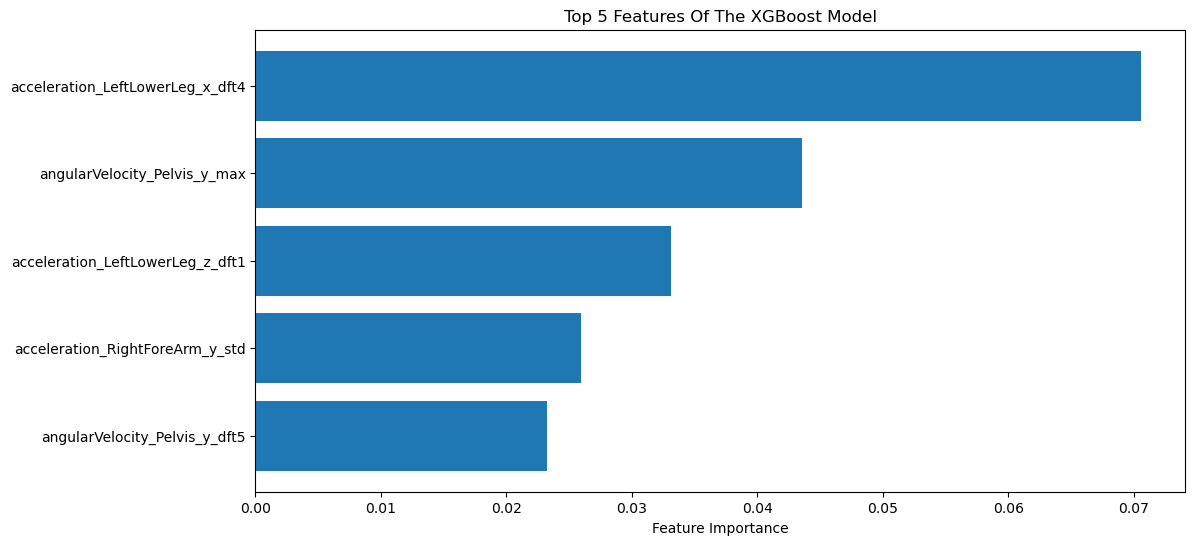

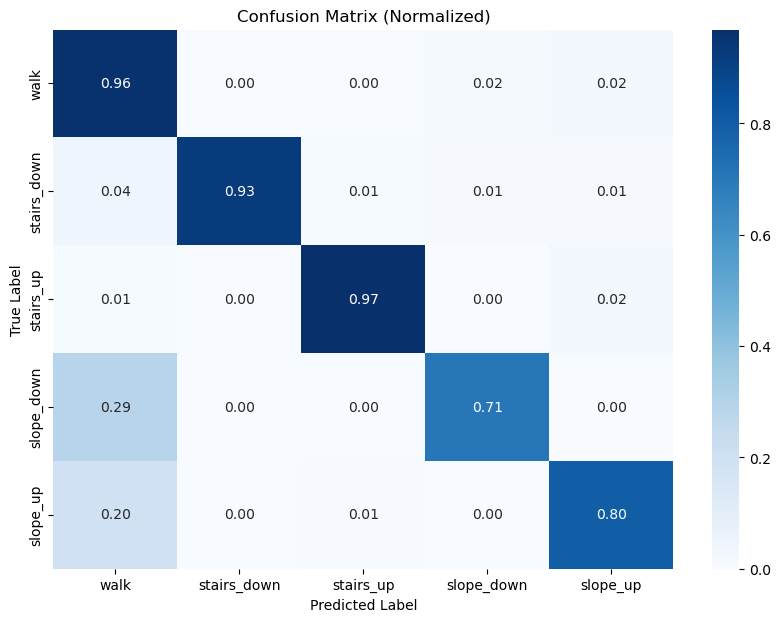

In [16]:
y = df["walk_mode"]
# Use LabelEncoder to convert string classes to numeric labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

participants = df["participant_id"].unique()

random.seed(2)
random.shuffle(participants)

# Assign a certain percentage of participants to the training set and the remaining to the test set
train_percentage = 0.8
num_train = int(train_percentage * len(participants))

train_participants = participants[:num_train]
test_participants = participants[num_train:]

# Use the participant list to filter the dataset into training and testing sets
train_set = df[df["participant_id"].isin(train_participants)]
test_set = df[df["participant_id"].isin(test_participants)]

# Split the data into features (X) and labels (y)
X_train, y_train = train_set[features], train_set["walk_mode"]
X_test, y_test = test_set[features], test_set["walk_mode"]

# X_train, X_test, y_train, y_test = train_test_split(df[features], y, test_size=0.2, stratify=y, random_state=42)

# Scale the data (not necessary with xgb)
# sc = MinMaxScaler()
# X_train = sc.fit_transform(X_train)
# X_test = sc.transform(X_test)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

####### only if classes start from 1 instead of 0 #######
# y_train = y_train - 1
# y_test = y_test - 1

# Hyperparameter tuning using GridSearchCV
param_grid = {
    "learning_rate": [0.1, 0.01, 0.001],
    "max_depth": [3, 5, 10],
    "n_estimators": [10, 40, 100, 150],
}
grid_search = GridSearchCV(
    estimator=XGBClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

print(best_params)

# Perform 5-fold cross-validation
cross_val_scores = cross_val_score(XGBClassifier(**best_params), X_train, y_train, cv=5)
# cross_val_scores = cross_val_score(XGBClassifier(), X_train, y_train, cv=5)
print("Cross-validation scores:", cross_val_scores)
print("Mean cross-validation score:", cross_val_scores.mean())

# Train the final model with the best hyperparameters
final_model = XGBClassifier(**best_params)
# final_model = XGBClassifier()

final_model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = final_model.predict(X_test)
classification_rep = classification_report(y_test, y_pred)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score (can use 'macro', 'micro', or 'weighted' average depending on preference)
f1 = f1_score(y_test, y_pred, average='macro')  # 'macro' averages F1 across all classes equally

# Sensitivity (Recall) - using 'macro' to calculate recall for each class and average
sensitivity = recall_score(y_test, y_pred, average='macro')  # Recall averaged across all classes

# Specificity - need to calculate per class and average
conf_matrix = confusion_matrix(y_test, y_pred)
specificity_per_class = []

for i in range(conf_matrix.shape[0]):
    # True Negatives are all the elements that are not in the i-th row and i-th column
    tn = np.sum(conf_matrix) - (np.sum(conf_matrix[i, :]) + np.sum(conf_matrix[:, i]) - conf_matrix[i, i])
    fp = np.sum(conf_matrix[:, i]) - conf_matrix[i, i]
    fn = np.sum(conf_matrix[i, :]) - conf_matrix[i, i]
    tp = conf_matrix[i, i]
    
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero
    specificity_per_class.append(specificity)

# Average specificity over all classes
specificity = np.mean(specificity_per_class)

# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score (Macro): {f1:.2f}")
print(f"Sensitivity (Recall - Macro): {sensitivity:.2f}")
print(f"Specificity (Average): {specificity:.2f}")
print("Classification Report:\n", classification_rep)

# Get feature importance scores
feature_importance = final_model.feature_importances_

# Create a DataFrame with feature names and their importance scores
feature_importance_df = pd.DataFrame(
    {"Feature": features, "Importance": feature_importance}
)

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

# Select the top 5 features
top_5_features = feature_importance_df.head(5)

# Plot the top 5 features
plt.figure(figsize=(12, 6))
plt.barh(top_5_features["Feature"][::-1], top_5_features["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 5 Features Of The XGBoost Model")
plt.show()

plot_confusion_matrix(y_test, y_pred, unique_vals)